the shape of train data (54808, 13)
the shape of test data (23490, 12)
<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 5.4 MB


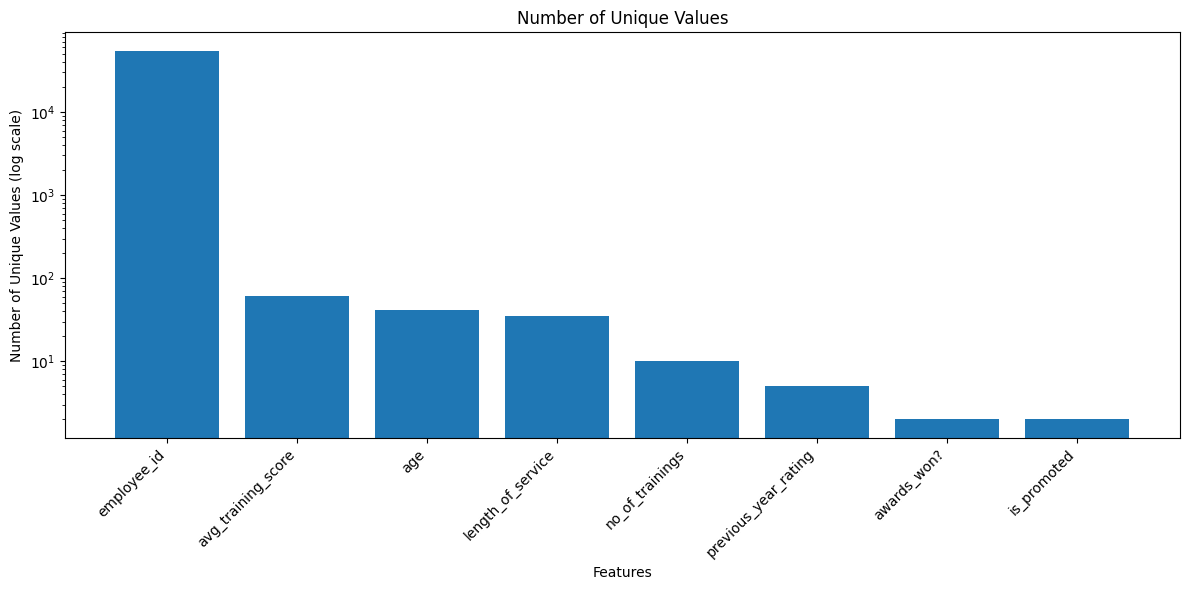

We have 0 duplicates in our dataset


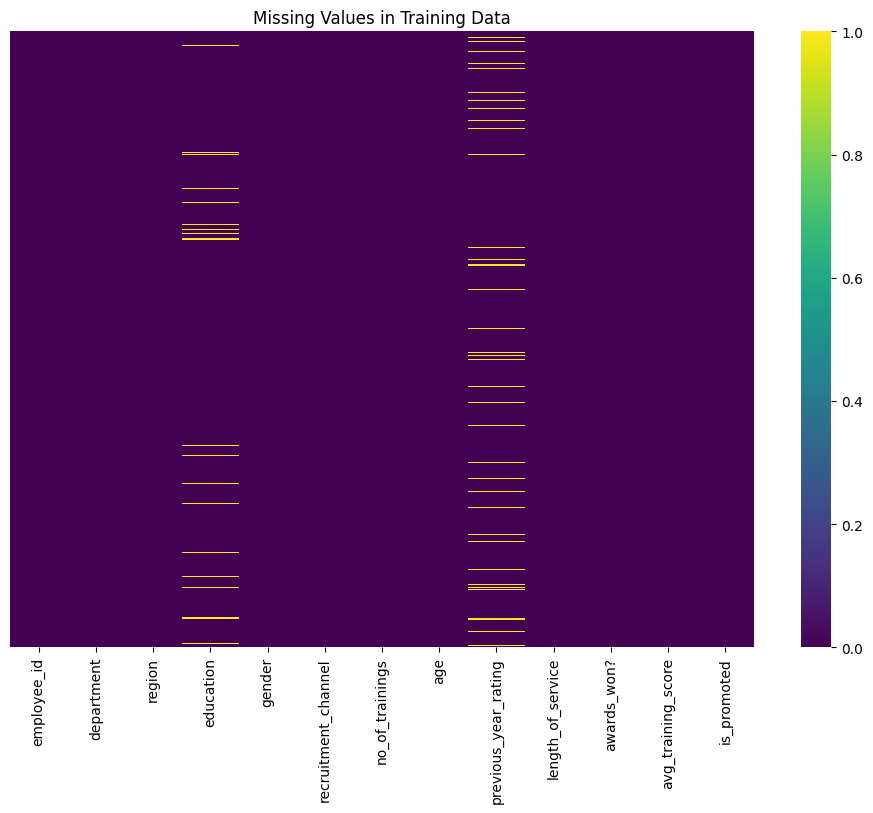

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64
Categorical columns: ['department', 'region', 'education', 'gender', 'recruitment_channel']
Numerical columns: ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score']
Class distribution:
is_promoted
0    50140
1     4668
Name: count, dtype: int64
Percentage of promoted: 8.52%
Original training shape: (43846, 53)
Resampled training shape: (80224, 53)
Class distribution after SMOTE:
is_promoted
0    40112
1    40112
Name: count, dtype: int64

Training Logistic Regression...
Accuracy: 0.7621
Precision: 0.2132
Recall: 0.6660
F1-Score: 0.3229
ROC-AUC: 0.79

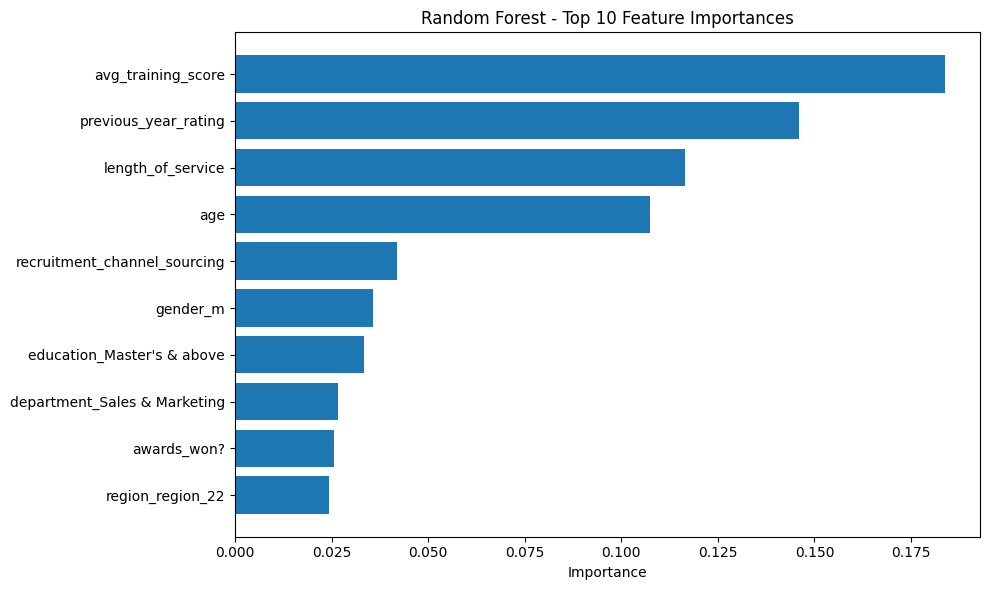


XGBOOST - TOP 10 FEATURE IMPORTANCES
                         feature  importance
12  department_Sales & Marketing    0.056400
2           previous_year_rating    0.049544
15              region_region_11    0.047684
27              region_region_22    0.044986
37              region_region_31    0.042176
48    education_Master's & above    0.032073
52  recruitment_channel_sourcing    0.031528
25              region_region_20    0.030264
3              length_of_service    0.027248
4                    awards_won?    0.025280


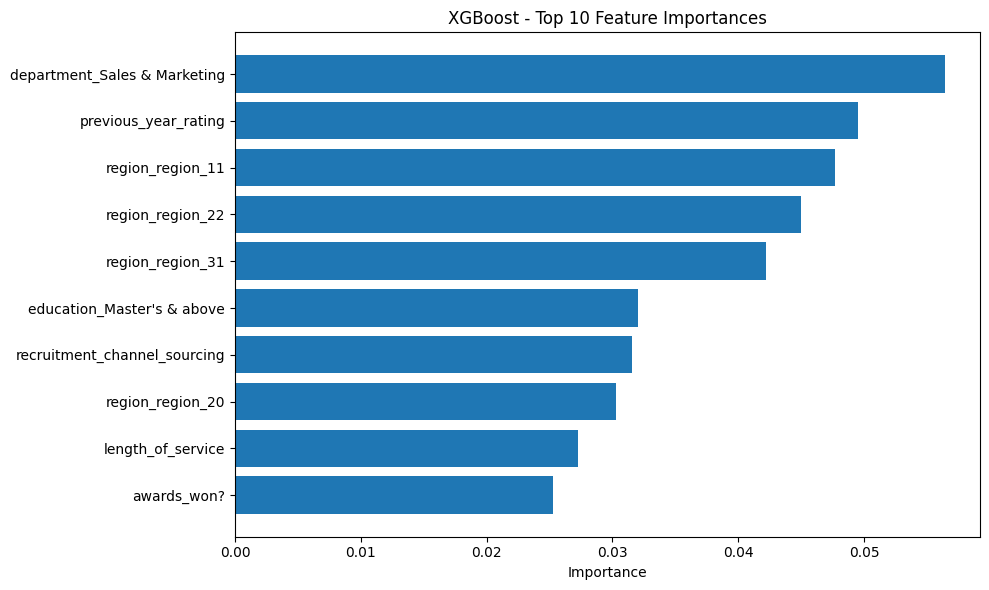


SHAP VALUES ANALYSIS


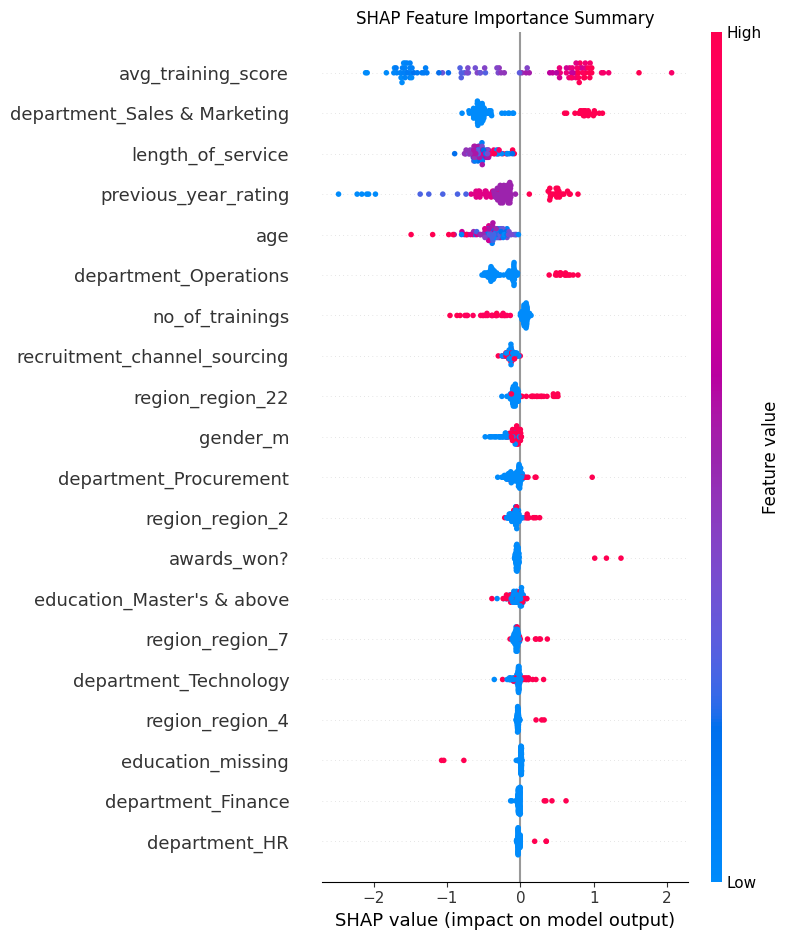


PREDICTIONS ON TEST DATA
Number of test samples: 23490
Predicted promotions: 763
Promotion rate: 3.25%

Predictions saved to 'predictions.csv'


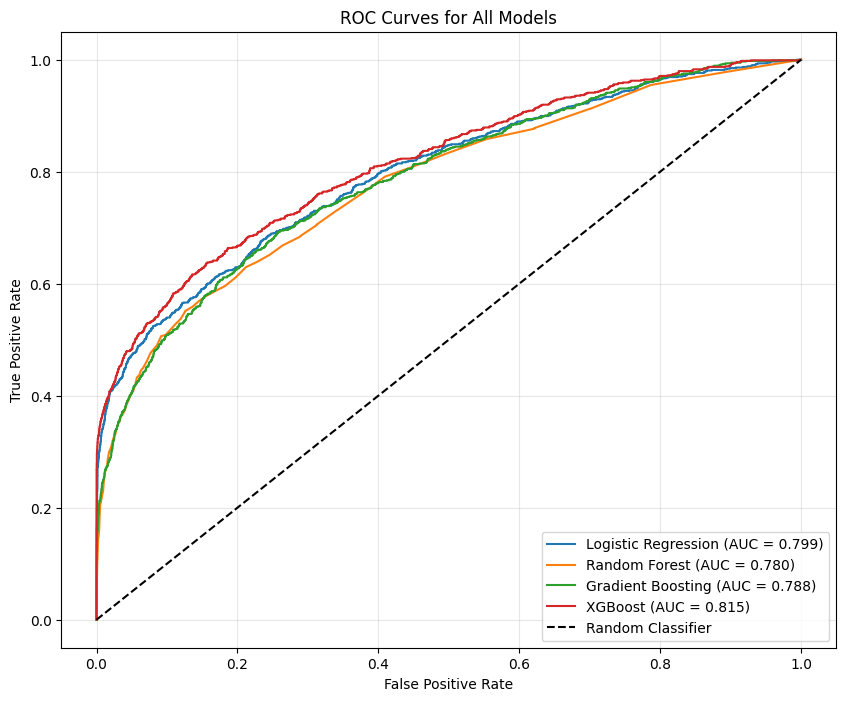

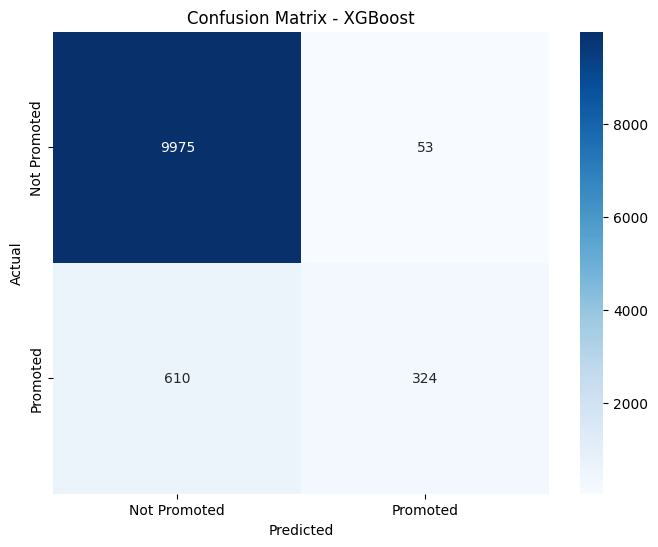

In [4]:
# PREDICTING EMPLOYEE PROMOTION

# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (18, 8)

import imblearn
import sklearn
import shap
import time
import warnings
warnings.filterwarnings('ignore')

# Import imputation module
from sklearn.impute import SimpleImputer

# ABOUT THE DATA
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('the shape of train data', train.shape)
print('the shape of test data', test.shape)

# EXPLORATORY DATA ANALYSIS
train.head()
train.describe()
train.describe(include='object')
train.is_promoted.value_counts()
pd.Series(train.dtypes).value_counts()
train.info()

# Number of Unique Values (using matplotlib)
unique_values = train.select_dtypes(include='number').nunique()
plt.figure(figsize=(12, 6))
unique_values_sorted = unique_values.sort_values(ascending=False)
plt.bar(range(len(unique_values_sorted)), unique_values_sorted.values)
plt.xticks(range(len(unique_values_sorted)), unique_values_sorted.index, rotation=45, ha='right')
plt.yscale('log')
plt.xlabel('Features')
plt.ylabel('Number of Unique Values (log scale)')
plt.title('Number of Unique Values')
plt.tight_layout()
plt.show()

# QUALITY INVESTIGATION - Missing Values
print(f'We have {train.duplicated().sum()} duplicates in our dataset')

# Visualize missing values
plt.figure(figsize=(12, 8))
sns.heatmap(train.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values in Training Data')
plt.show()

print(train.isnull().sum())

# DATA PREPROCESSING - Separate features and target
X = train.drop('is_promoted', axis=1)
y = train['is_promoted']
X = X.drop('employee_id', axis=1)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

# CREATE PREPROCESSOR PIPELINE WITH IMPUTER
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create separate pipelines for numerical and categorical columns
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle NaN with median
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Handle NaN in categorical
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ])

# Apply preprocessing to training data
X_processed = preprocessor.fit_transform(X)

# Get feature names after preprocessing
feature_names = (list(numerical_cols) + 
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_cols)))

# Check class imbalance
print(f"Class distribution:\n{y.value_counts()}")
print(f"Percentage of promoted: {y.mean()*100:.2f}%")

# HANDLE CLASS IMBALANCE WITH SMOTE (now without NaN values)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split data first
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only on training data (no NaN values now)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# MODEL TRAINING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                            roc_curve, accuracy_score, precision_score, recall_score, f1_score)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

# Compare model performance
results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['accuracy'],
        'Precision': results[name]['precision'],
        'Recall': results[name]['recall'],
        'F1-Score': results[name]['f1_score'],
        'ROC-AUC': results[name]['roc_auc']
    }
    for name in results.keys()
}).T

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.round(4))

# Find best model
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = results[best_model_name]['model']
print(f"\nBest Model: {best_model_name} with ROC-AUC = {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")

# FEATURE IMPORTANCE (for tree-based models)
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    rf_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nRANDOM FOREST - TOP 10 FEATURE IMPORTANCES")
    print(rf_importance.head(10))
    
    plt.figure(figsize=(10, 6))
    top_rf = rf_importance.head(10)
    plt.barh(top_rf['feature'], top_rf['importance'])
    plt.xlabel('Importance')
    plt.title('Random Forest - Top 10 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

if 'XGBoost' in results:
    xgb_model = results['XGBoost']['model']
    xgb_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nXGBOOST - TOP 10 FEATURE IMPORTANCES")
    print(xgb_importance.head(10))
    
    plt.figure(figsize=(10, 6))
    top_xgb = xgb_importance.head(10)
    plt.barh(top_xgb['feature'], top_xgb['importance'])
    plt.xlabel('Importance')
    plt.title('XGBoost - Top 10 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# SHAP VALUES (optional, may still cause issues if shap not properly installed)
print("\n" + "="*60)
print("SHAP VALUES ANALYSIS")
print("="*60)

try:
    if 'XGBoost' in results:
        explainer = shap.TreeExplainer(results['XGBoost']['model'])
        shap_values = explainer.shap_values(X_val[:100])
        shap.summary_plot(shap_values, X_val[:100], feature_names=feature_names, show=False)
        plt.title('SHAP Feature Importance Summary')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"SHAP plot error (optional, can be ignored): {e}")

# PREDICTION ON TEST DATA
X_test = test.drop('employee_id', axis=1)
X_test_processed = preprocessor.transform(X_test)

test_predictions = best_model.predict(X_test_processed)
test_probabilities = best_model.predict_proba(X_test_processed)[:, 1]

submission = pd.DataFrame({
    'employee_id': test['employee_id'],
    'is_promoted': test_predictions,
    'probability': test_probabilities
})

print("\n" + "="*60)
print("PREDICTIONS ON TEST DATA")
print("="*60)
print(f"Number of test samples: {len(submission)}")
print(f"Predicted promotions: {submission['is_promoted'].sum()}")
print(f"Promotion rate: {submission['is_promoted'].mean()*100:.2f}%")

submission.to_csv('predictions.csv', index=False)
print("\nPredictions saved to 'predictions.csv'")

# ROC Curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_val, result['y_pred_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Confusion Matrix for Best Model
cm = confusion_matrix(y_val, results[best_model_name]['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Promoted', 'Promoted'],
            yticklabels=['Not Promoted', 'Promoted'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()